# NeqSim CO2 Impurity Kinetics: 100-Hour CSTR Tutorial

> **Experimental screening model.** The bundled kinetics and fallback thermodynamic correlation
> are illustrative and uncalibrated. The results are not qualified engineering design data.

This notebook demonstrates the high-level `CO2ImpurityReactorExperiment` API for a 100-hour,
three-phase CSTR-style screening simulation.

### API features

1. System and vessel configuration
2. Sequential feed phases
3. Geometry and residence-time reporting
4. Tabular results
5. Three-panel visualization


In [1]:
import warnings

import matplotlib.pyplot as plt
from neqsim_co2_kinetics import CO2ImpurityReactorExperiment

warnings.filterwarnings(
    "ignore",
    message="NeqSim Python thermodynamics is unavailable*",
    category=RuntimeWarning,
)
print("CO2 impurity experiment manager imported.")


CO2 impurity experiment manager imported.


## 1. System and vessel metadata

We specify target pressure ($25	ext{ bar}$), target temperature
($-25^\circ	ext{C}$), reactor geometry ($D = 6.5	ext{ cm}$,
$V = 300	ext{ mL}$), and mass flow rate ($50	ext{ g/h}$).

The initial $	ext{N}_2$ charge is recorded as metadata. Nitrogen is not one of the tracked
impurity species and is not included in the tutorial ODE balance.


In [2]:
# Initialize the CO2 experiment system.
exp = CO2ImpurityReactorExperiment(
    target_pressure_bar=25.0,
    target_temp_C=-25.0,
    diameter_cm=6.50,
    volume_ml=300.0,
    mass_flow_g_h=50.0,
    material="carbon_steel",
)

# Record initial vessel-charge metadata.
exp.set_initial_vessel_charge(
    gas_name="N2",
    pressure_bar=1.0,
    temp_C=25.0,
)

print("Experiment system initialized.")
print(f"Thermodynamic backend: {exp.model.thermodynamic_backend}")


Experiment system initialized.
Thermodynamic backend: illustrative screening correlation


## 2. Automated Geometry & Hydrodynamic Residence Time Report

Calling `exp.generate_reactor_report()` automatically derives the reactor length $L$ and hydrodynamic residence time $\tau$.

In [3]:
# Print automated reactor derivation report
report = exp.generate_reactor_report()
print("=" * 100)
print(report)
print("=" * 100)

1. Reactor Geometry & Length (L) Derivation
Target Volume (V): 300.0 mL = 300.0 cm3 = 3.0e-04 m3
Inner Diameter (D): 6.50 cm = 0.0650 m
Cross-Sectional Area (A_cross): A_cross = pi * D^2 / 4 = pi * (6.50 cm)^2 / 4 = 33.1831 cm2 (3.31831e-03 m2)
Calculated Reactor Length (L): L = V / A_cross = 300.0 cm3 / 33.1831 cm2 = 9.0408 cm (0.090408 m)

2. Hydrodynamic Residence Time (tau) at 25.0 bar, -25.0°C
Fluid density from illustrative screening correlation: Liquid CO2 density rho = 1057.72 kg/m3 (rho_m = 24.0339 kmol/m3).
Liquid Mass Inventory: m_reactor = 300.0 mL * 1.05772 g/mL = 317.32 grams of liquid CO2.
Mass Flow Rate (m_dot): 50.0 g/h.
CSTR Residence Time (tau): tau = m_reactor / m_dot = 317.32 g / 50.0 g/h = 6.3463 HOURS (22846.8 seconds)
Initial vessel charge metadata: N2, 1.000 bar, 25.000 °C (not included in the impurity-species ODE balance)


## 3. Adding Experimental Phases for 100 Hours (add_phase)

We add 3 sequential phases for a total duration of 100 hours:
- **Phase 0 (10 h)**: Pure $\text{CO}_2$ Pressurization & Flow Out Constant Volume.
- **Phase 1 (40 h)**: $10\text{ ppm}$ feed **WITHOUT $\text{H}_2\text{S}$** ($0\text{ ppm }\text{H}_2\text{S}$).
- **Phase 2 (50 h)**: **ALL $10\text{ ppm}$ impurities INCLUDING $\text{H}_2\text{S}$**.

In [4]:
# Clear any existing phases
exp.clear_phases()

# Phase 0: Pure CO2 Pressurization & Flow Out (10 hours)
exp.add_phase(duration_hours=10.0, feed_ppm={'H2S': 0, 'SO2': 0, 'NO2': 0, 'O2': 0, 'H2O': 0}, phase_name="Phase 0: Pure CO2 Pressurization")

# Phase 1: 10 ppm Feed WITHOUT H2S (40 hours)
exp.add_phase(duration_hours=40.0, feed_ppm={'SO2': 10, 'NO2': 10, 'O2': 10, 'H2O': 10}, phase_name="Phase 1: 10 ppm Without H2S (40h)")

# Phase 2: 10 ppm Feed WITH ALL IMPURITIES (50 hours)
exp.add_phase(duration_hours=50.0, feed_ppm={'H2S': 10, 'SO2': 10, 'NO2': 10, 'O2': 10, 'H2O': 10}, phase_name="Phase 2: 10 ppm All Impurities (50h)")

# Run experiment across all phases
sim_res = exp.run_experiment()
print("100-Hour Multi-Phase Experiment Run Successfully Completed!")

100-Hour Multi-Phase Experiment Run Successfully Completed!


## 4. Master Concentration Table (0 to 100 h at 2-Hour Resolution)

We call `exp.get_table_results(resolution_hours=2.0)` to generate the master concentration table at 2-hour intervals from $0.0$ to $100.0\text{ hours}$.

In [5]:
# Get master 2-hour resolution table (0 to 100 h)
df_results_100h = exp.get_table_results(resolution_hours=2.0)

print("=" * 110)
print("MASTER 100-HOUR EXPERIMENT CONCENTRATION TABLE (2-HOUR RESOLUTION)")
print("=" * 110)
df_results_100h

MASTER 100-HOUR EXPERIMENT CONCENTRATION TABLE (2-HOUR RESOLUTION)


,Time (h),H2S (ppm),SO2 (ppm),NO2 (ppm),NO (ppm),O2 (ppm),H2O (ppm),H2SO4 (ppm),HNO3 (ppm),NH3 (ppm),S8 (ppm)
0,0.0,0.00,0.00,0.00,0.0000,0.00,0.00,0.0000,0.0,0.0000,0.0
1,2.0,0.00,0.00,0.00,0.0000,0.00,0.00,0.0000,0.0,0.0000,0.0
2,4.0,0.00,0.00,0.00,0.0000,0.00,0.00,0.0000,0.0,0.0000,0.0
3,6.0,0.00,0.00,0.00,0.0000,0.00,0.00,0.0000,0.0,0.0000,0.0
4,8.0,0.00,0.00,0.00,0.0000,0.00,0.00,0.0000,0.0,0.0000,0.0
5,10.0,0.00,0.00,0.00,0.0000,0.00,0.00,0.0000,0.0,0.0000,0.0
6,12.0,0.00,2.70,2.70,0.0000,2.70,2.70,0.0002,0.0,0.0000,0.0
7,14.0,0.00,4.67,4.68,0.0000,4.67,4.67,0.0019,0.0,0.0000,0.0
8,16.0,0.00,6.11,6.11,0.0000,6.11,6.11,0.0056,0.0,0.0000,0.0
9,18.0,0.00,7.15,7.17,0.0000,7.16,7.15,0.0111,0.0,0.0000,0.0


## 5. Three-panel plot

`exp.plot_results()` creates three panels for reactants, sulfuric acid, and the remaining products.
The plot is retained in the executed notebook output.


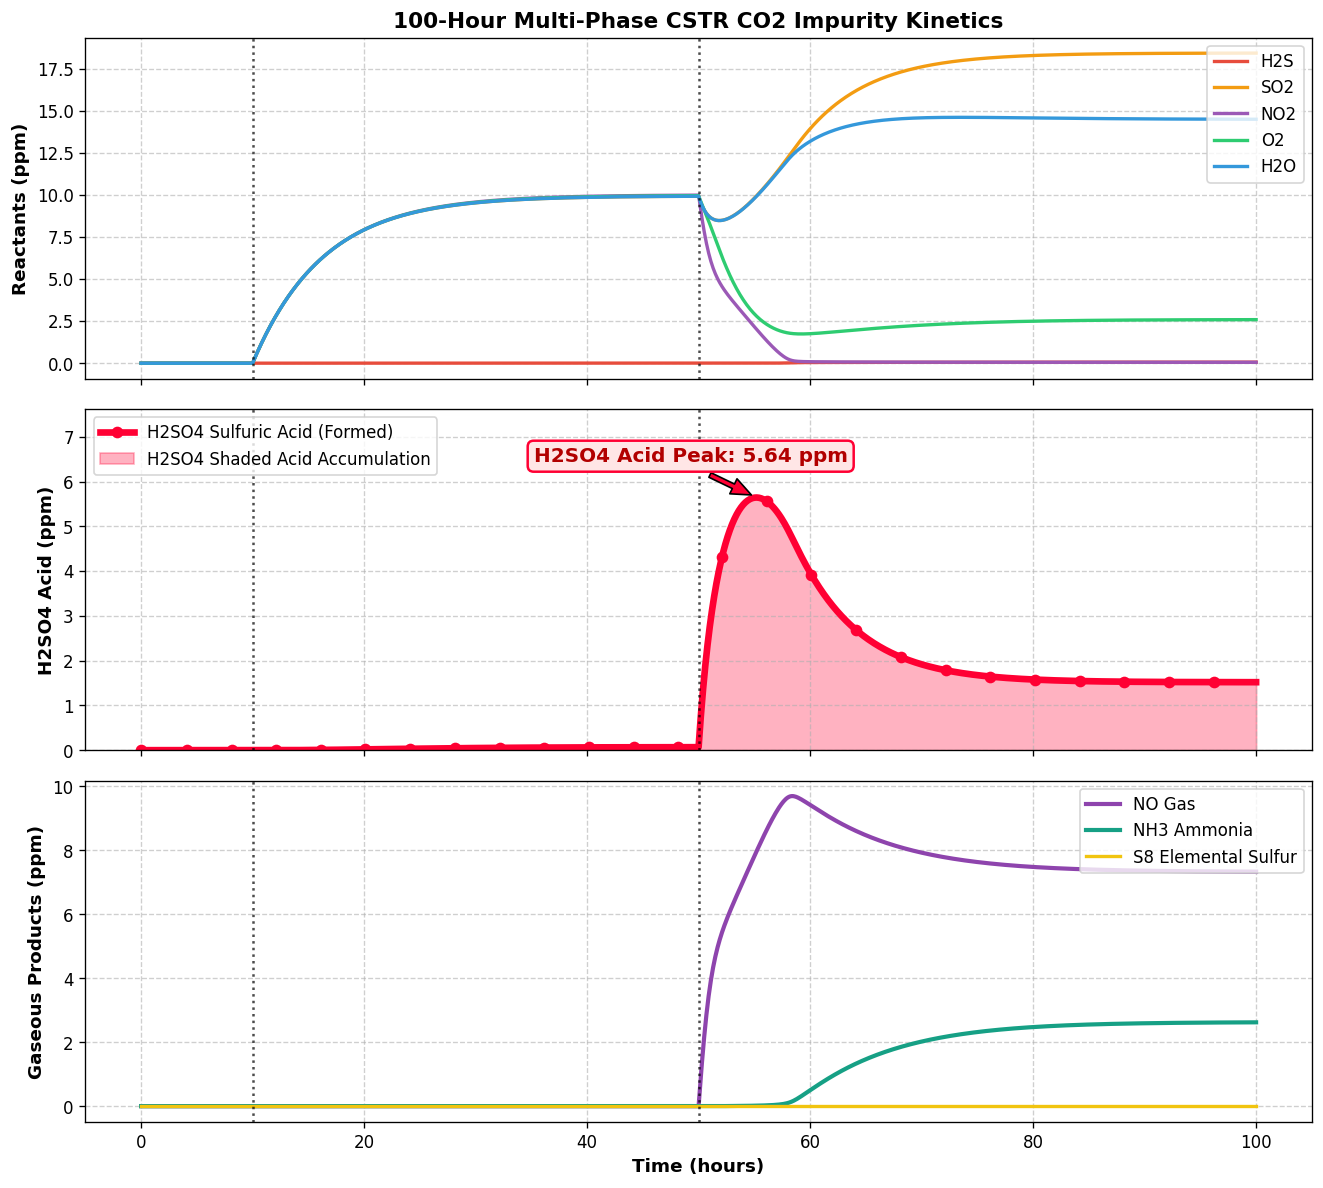

In [6]:
exp.plot_results(title="100-Hour Multi-Phase CSTR CO2 Impurity Kinetics")
plt.show()
